# XenoCanto 0.1.0 vs 0.2.0 (vs BirdSet XCL)

alp-data 1.11.0 adds a `version` parameter to `XenoCanto` (`0.1.0` = 20260203 split, `0.2.0` = Jun 2026 / 20260622 dump). This notebook compares the two on the **metadata level** and on the **downstream-relevant** view for the BirdSet evaluation classes.

As a third reference we add the **BirdSet XCL** dump (the Xeno-Canto pool BirdSet itself trains on), read from HuggingFace. XCL contains only `A`/`B`/`C` quality recordings, so we also build **quality-dropped (A–C) variants** of both XC dumps as like-for-like comparisons.

Both XC versions share the same audio root; only the split CSVs differ, so this reads metadata only (no audio).

> **Note on keys:** our XC dumps identify species by GBIF `gbifID`; XCL identifies them by `ebird_code`. There is no shared id column, so XC-vs-XC comparisons use `gbifID` and XCL comparisons use `ebird_code`. Per BirdSet subset the two class spaces are equivalent (same species, ±1 from id-mapping quirks), so the per-subset *recording counts* are directly comparable even though each is derived via its dump's native key.
>
> **Quality on 0.1.0:** the `quality` column only exists in XC 0.2.0. To build an A–C 0.1.0, we borrow each recording's quality from 0.2.0 via `xc_id` (the XenoCanto recording id — the numeric part of the file name, e.g. `XC700008…` → `700008`). ~0.9% of 0.1.0 recordings are absent from the newer dump (unknown quality) and are dropped from the A–C variant.

In [1]:
import json
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from alp_data.datasets import XenoCanto, BirdSet


def frame(backend) -> pl.DataFrame:
    """Materialize an alp-data PolarsBackend to an eager polars DataFrame."""
    df = backend.unwrap  # `unwrap` is a property, not a method
    return df.collect() if isinstance(df, pl.LazyFrame) else df


def load_xc(version: str) -> pl.DataFrame:
    return frame(XenoCanto(version=version, split="all")._data)


d01, d02 = load_xc("0.1.0"), load_xc("0.2.0")

# A-C variant of 0.2.0: it has its own `quality` column.
d02_ac = d02.filter(pl.col("quality").is_in(["A", "B", "C"]))

# A-C variant of 0.1.0: borrow quality from 0.2.0 via xc_id, then keep A-C.
_q = d02.select(["xc_id", "quality"]).unique(subset="xc_id")
d01_q = d01.join(_q, on="xc_id", how="left")
d01_ac = d01_q.filter(pl.col("quality").is_in(["A", "B", "C"]))

XCL_URL = "https://huggingface.co/datasets/DBD-research-group/BirdSet/resolve/data/XCL/XCL_metadata.parquet?download=true"
xcl = pd.read_parquet(XCL_URL)

{
    "XC 0.1.0": d01.height,
    "XC 0.1.0 (A-C)": d01_ac.height,
    "XC 0.2.0": d02.height,
    "XC 0.2.0 (A-C)": d02_ac.height,
    "XCL": len(xcl),
}

{'XC 0.1.0': 596526,
 'XC 0.1.0 (A-C)': 555031,
 'XC 0.2.0': 744242,
 'XC 0.2.0 (A-C)': 692114,
 'XCL': 528422}

## 1. Metadata-level comparison

### 1.1 Volume and schema

In [2]:
matched = d01_q["quality"].is_not_null().sum()

print(f"rows      0.1.0={d01.height:>8,}   0.2.0={d02.height:>8,}   XCL={len(xcl):>8,}")
print(f"          0.1.0->0.2.0: +{d02.height - d01.height:,} ({100*(d02.height/d01.height - 1):.1f}%)")
print(f"          0.1.0 A-C (quality via xc_id from 0.2.0): {d01_ac.height:>8,} rows "
      f"(-{d01.height - d01_ac.height:,}; {100*matched/d01.height:.1f}% matched)")
print(f"          0.2.0 A-C (D/E/no-score dropped)        : {d02_ac.height:>8,} rows "
      f"(-{d02.height - d02_ac.height:,})")
print(f"columns   0.1.0={len(d01.columns):>8}   0.2.0={len(d02.columns):>8}")
print()
print("new columns in 0.2.0    :", [c for c in d02.columns if c not in d01.columns])
print("dropped columns in 0.2.0:", [c for c in d01.columns if c not in d02.columns])

rows      0.1.0= 596,526   0.2.0= 744,242   XCL= 528,422
          0.1.0->0.2.0: +147,716 (24.8%)
          0.1.0 A-C (quality via xc_id from 0.2.0):  555,031 rows (-41,495; 99.1% matched)
          0.2.0 A-C (D/E/no-score dropped)        :  692,114 rows (-52,128)
columns   0.1.0=      83   0.2.0=      87

new columns in 0.2.0    : ['gcs_path', 'url', 'quality', 'ingestion_date']
dropped columns in 0.2.0: []


### 1.2 Species / taxon coverage

`gbifID` is the taxon key used downstream by our XC dumps; XCL is counted by `ebird_code`.

In [3]:
def gbif_taxa(df: pl.DataFrame) -> set:
    return set(df.filter(pl.col("gbifID").is_not_null())["gbifID"].cast(pl.Int64).to_list())


t01, t02 = gbif_taxa(d01), gbif_taxa(d02)
print(f"unique gbif taxa   0.1.0={len(t01):>6}   0.2.0={len(t02):>6}")
print(f"  A-C variants     0.1.0={len(gbif_taxa(d01_ac)):>6}   0.2.0={len(gbif_taxa(d02_ac)):>6}")
print(f"  taxa only in 0.1.0 : {len(t01 - t02)}")
print(f"  taxa only in 0.2.0 : {len(t02 - t01)}")
print(f"  shared taxa        : {len(t01 & t02)}")
print(f"unique ebird species  XCL={xcl['ebird_code'].nunique():>6}")

unique gbif taxa   0.1.0= 10799   0.2.0= 11748


  A-C variants     0.1.0= 10705   0.2.0= 11656
  taxa only in 0.1.0 : 2
  taxa only in 0.2.0 : 951
  shared taxa        : 10797
unique ebird species  XCL=  9734


### 1.3 Recording `quality` field

New in XC 0.2.0 (absent in 0.1.0); XCL also carries it. XenoCanto quality rating `A` (best) … `E` (worst), plus `no score` / null. XCL keeps only A/B/C.

In [4]:
q_02 = d02["quality"].value_counts().to_pandas().set_index("quality")["count"]
q_01 = d01_q["quality"].value_counts().to_pandas().set_index("quality")["count"]  # borrowed via xc_id
q_xcl = xcl["quality"].value_counts(dropna=False)
quality = pd.DataFrame({"XC 0.1.0*": q_01, "XC 0.2.0": q_02, "XCL": q_xcl}).fillna(0).astype(int)
quality = quality.reindex(quality.index.astype(str).sort_values())
print("* 0.1.0 quality is borrowed from 0.2.0 via xc_id; NaN = 0.1.0 recordings absent from 0.2.0")
quality

* 0.1.0 quality is borrowed from 0.2.0 via xc_id; NaN = 0.1.0 recordings absent from 0.2.0


,XC 0.1.0*,XC 0.2.0,XCL
quality,,,
A,149835,181911,187946
B,277430,348891,238851
C,127766,161312,101625
D,29831,38879,0
E,6510,7931,0
no score,0,368,0
NaN,5154,4950,0


## 2. Downstream view: BirdSet evaluation classes

Each BirdSet subset defines a fixed class list. Training data (XC / XCL) is filtered to those classes. The downstream question: **how much in-class training data does each dump provide, does 0.2.0 fill previously-missing species, and how do the A–C-dropped XC dumps compare to XCL?**

- XC variants use the test set's `gbifID_multispecies` classes, counted against XC `gbifID`.
- XCL uses the test set's `ebird_code_multilabel` classes, counted against XCL `ebird_code`.

In [5]:
SUBSETS = ["HSN", "NBP", "NES", "PER", "POW", "SSW", "SNE", "UHH"]


def birdset_test(subset: str) -> pl.DataFrame:
    return frame(BirdSet(split=f"{subset}-test_5s")._data)


def gbif_classes(df: pl.DataFrame) -> list[str]:
    """GBIF taxon ids (str) making up a subset's class list."""
    return (
        df.select(pl.col("gbifID_multispecies").str.extract_all(r"\d+").alias("g"))
        .explode("g").drop_nulls()["g"].unique().to_list()
    )


def ebird_classes(df: pl.DataFrame) -> set:
    """eBird codes making up a subset's class list."""
    codes = set()
    for v in df["ebird_code_multilabel"].to_list():
        if v is None:
            continue
        try:
            codes.update(json.loads(v))
        except Exception:
            codes.update(str(v).replace("[", "").replace("]", "").replace("'", "").split(","))
    codes.discard("")
    return codes


def xc_counts_by_taxon(df: pl.DataFrame) -> dict[str, int]:
    c = (
        df.filter(pl.col("gbifID").is_not_null())
        .with_columns(pl.col("gbifID").cast(pl.Int64).cast(pl.Utf8).alias("gid"))
        .group_by("gid").len()
    )
    return dict(zip(c["gid"].to_list(), c["len"].to_list()))


cnt01 = xc_counts_by_taxon(d01)
cnt01_ac = xc_counts_by_taxon(d01_ac)
cnt02 = xc_counts_by_taxon(d02)
cnt02_ac = xc_counts_by_taxon(d02_ac)
cnt_xcl = xcl["ebird_code"].value_counts().to_dict()
bs_test = {s: birdset_test(s) for s in SUBSETS}

In [6]:
rows = []
for s in SUBSETS:
    gids = gbif_classes(bs_test[s])
    ecodes = ebird_classes(bs_test[s])
    rows.append(
        {
            "subset": s,
            "classes": len(gids),
            "missing_0.2.0": sum(1 for g in gids if g not in cnt02),
            "missing_XCL": sum(1 for c in ecodes if c not in cnt_xcl),
            "rec_0.1.0": sum(cnt01.get(g, 0) for g in gids),
            "rec_0.1.0_AC": sum(cnt01_ac.get(g, 0) for g in gids),
            "rec_0.2.0": sum(cnt02.get(g, 0) for g in gids),
            "rec_0.2.0_AC": sum(cnt02_ac.get(g, 0) for g in gids),
            "rec_XCL": sum(cnt_xcl.get(c, 0) for c in ecodes),
        }
    )

coverage = pl.DataFrame(rows)
coverage

subset,classes,missing_0.2.0,missing_XCL,rec_0.1.0,rec_0.1.0_AC,rec_0.2.0,rec_0.2.0_AC,rec_XCL
str,i64,i64,i64,i64,i64,i64,i64,i64
"""HSN""",21,0,0,6048,5686,7193,6724,5460
"""NBP""",51,0,0,87238,80742,108217,100016,79474
"""NES""",88,0,0,17786,16783,20215,19076,16116
"""PER""",131,1,0,17970,17012,20663,19556,16802
"""POW""",48,0,0,16631,15561,19641,18383,14911
"""SSW""",81,0,0,31620,29441,37559,34944,28403
"""SNE""",55,0,0,20770,19391,23891,22248,19389
"""UHH""",27,2,2,4167,3881,4998,4638,3626


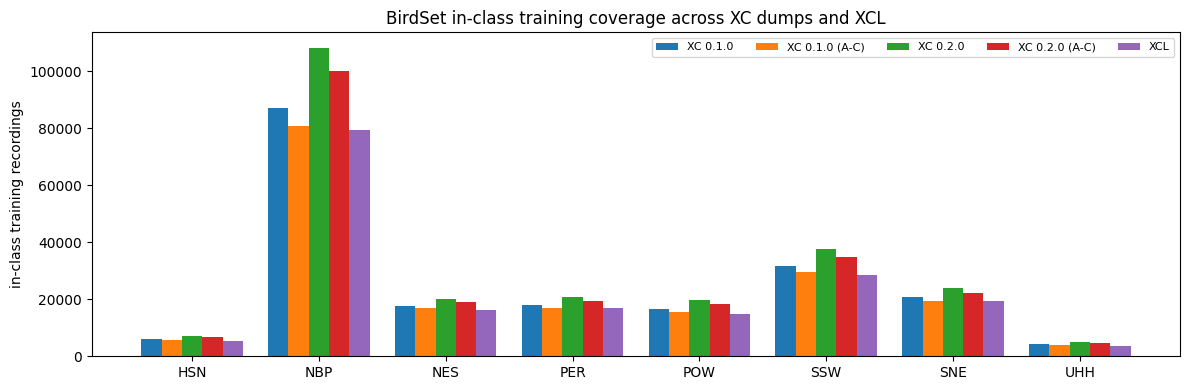

In [7]:
series = [
    ("rec_0.1.0", "XC 0.1.0"),
    ("rec_0.1.0_AC", "XC 0.1.0 (A-C)"),
    ("rec_0.2.0", "XC 0.2.0"),
    ("rec_0.2.0_AC", "XC 0.2.0 (A-C)"),
    ("rec_XCL", "XCL"),
]
fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(SUBSETS))
w = 0.16
offsets = [(-2 + i) * w for i in range(len(series))]
for (col, label), off in zip(series, offsets):
    ax.bar([i + off for i in x], coverage[col], w, label=label)
ax.set_xticks(list(x))
ax.set_xticklabels(SUBSETS)
ax.set_ylabel("in-class training recordings")
ax.set_title("BirdSet in-class training coverage across XC dumps and XCL")
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

## Takeaways

- **Volume:** XC 0.2.0 is ~+25% over 0.1.0 (596,526 → 744,242). Restricting to A–C leaves 692,114 (0.2.0) and 555,031 (0.1.0, quality borrowed via `xc_id`; ~0.9% of 0.1.0 has no match in 0.2.0 and is dropped). All XC variants exceed the XCL pool (528,422) — XCL is BirdSet's more aggressively filtered/deduplicated set.
- **Schema:** 0.2.0 adds `quality` (A–E rating), plus `gcs_path`, `url`, `ingestion_date`. Nothing is dropped. (The changelog's `playback_used` field is **not** present.)
- **Quality:** XC 0.2.0 spans A–E (+ `no score`/null); XCL only contains A/B/C. The A–C drop costs ~7% of recordings but essentially no BirdSet-class species.
- **Downstream (BirdSet):** 0.1.0 → 0.2.0 adds ~13–24% more in-class recordings, but no subset gains a *new* species — the extra data is depth on already-covered classes. Species missing from XC (PER: 1, UHH: 2 by gbifID) stay missing; UHH is short 2 species even in XCL, so that gap is intrinsic to Xeno-Canto.
- **A–C-dropped XC vs XCL:** even after matching XCL's quality range, both A–C XC variants stay above XCL per subset. So the volume gap over XCL is driven by **de-duplication, not quality filtering** — matching quality alone doesn't reproduce the XCL pool size.